In [1]:
import re
import os
import ast
import matplotlib
from dataclasses import dataclass, field
from collections import defaultdict
MATCH_PARA = re.compile(r'(\w+)\s+([\d.]+)')
import matplotlib.pyplot as plt
import math
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import numpy as np
from matplotlib.ticker import FuncFormatter
def format_k(value, tick_number):
    return f"{value / 1000:.1f}k"
formatter = FuncFormatter(format_k)

from matplotlib.ticker import FixedLocator
from Utils import *
data_path = "quantum_network_compiler-minimal_codes/FIG_dataset_rebuttal"
current_dir = os.getcwd()
parent_dir = os.path.dirname(os.path.dirname(current_dir))
absolute_path = os.path.join(parent_dir, data_path)
data_path = str(os.path.abspath(absolute_path))
data_path_to_execute = data_path + '/cache_size'
data_path_list = [data_path+'/split_mul']
benchmark = ['xor','qft','grover','rca', 'qaoa']
eval = ['split_mul']
line_width = 3
marker_size = 8

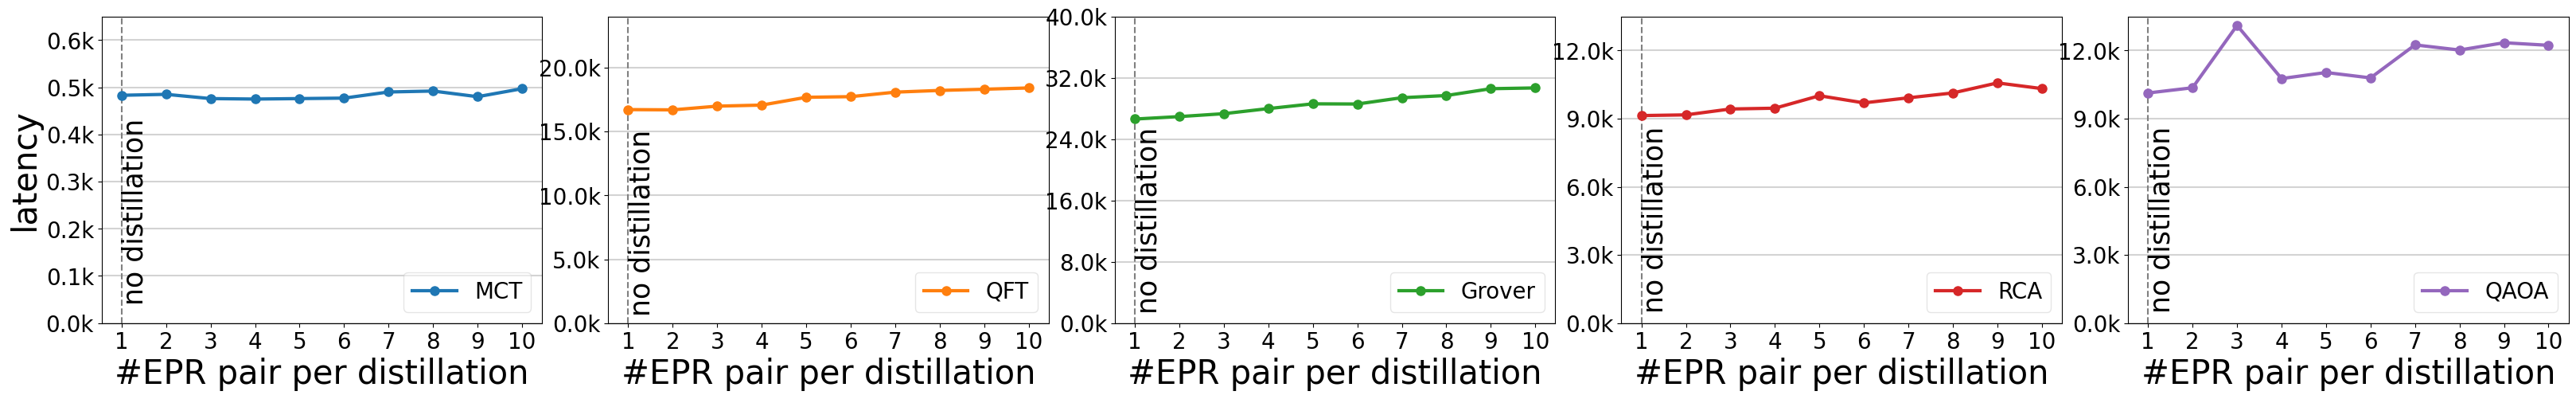

In [2]:
tick_font = 20
labelpad = 10
fig, axs = plt.subplots(1, 5, figsize=(40, 5), gridspec_kw={'wspace': 0.15})
normalize = False

label_mapping = {
    "Benchmark-0": "MCT",
    "Benchmark-0-baseline": "MCT-baseline",
    "Benchmark-1": "QFT",
    "Benchmark-1-baseline": "QFT-baseline",
    "Benchmark-2": "Grover",
    "Benchmark-2-baseline": "Grover-baseline",
    "Benchmark-3": "RCA",
    "Benchmark-3-baseline": "RCA-baseline",
    "Benchmark-4": "QAOA",
    "Benchmark-4-baseline": "QAOA-baseline"

}
plt.subplots_adjust(wspace=0.1, hspace=0.2)
diction_our, diction_baseline = compute_dictionaries(data_path_list[0], eval[0], benchmark)
diction_our_const = diction_our
d = 0.005
x_coor = range(1,11)
xlabel = '#EPR pair per distillation'

#FIG 10 c1
i = 0
diction_our[0][i] = diction_our_const[0][i][:10]
ylabel1 = 'latency'
ss = axs[0].get_subplotspec()
axs[i].set_yticklabels([])                  
axs[i].set_xticklabels([])                   
axs[0].set_ylabel(ylabel1, fontsize=30, color='black')
axs[0].vlines(x_coor[0],ymin = 0, ymax = 1000,  colors='gray', linestyles='dashed', linewidth=1.5)
axs[0].text(1,50,'no distillation',rotation = 90, fontsize = 25)
axs[0].xaxis.set_major_locator(FixedLocator(x_coor))
axs[0].yaxis.set_major_formatter(formatter)
axs[0].set_xticklabels([1,2,3,4,5,6,7,8,9,10])


#FIG 10 c2
i = 1
diction_our[0][i] = diction_our_const[0][i][:10]
max_y = max(max([a/diction_baseline[0][i][0] for a in diction_our[0][i]]), diction_baseline[0][i][0]) if normalize else max(max(diction_our[0][i]), diction_baseline[0][i][0])
axs[1].vlines(x_coor[0],ymin = 0, ymax = 25000,  colors='gray', linestyles='dashed', linewidth=1.5)
axs[1].text(1,1000,'no distillation',rotation = 90, fontsize = 25)
axs[1].set_xticks(x_coor)


#FIG 10 c3
i = 2
diction_our[0][i] = diction_our_const[0][i][:10]
max_y = max(max([a/diction_baseline[0][i][0] for a in diction_our[0][i]]), diction_baseline[0][i][0]) if normalize else max(max(diction_our[0][i]), diction_baseline[0][i][0])
axs[2].vlines(x_coor[0],ymin = 0, ymax = 200000,  colors='gray', linestyles='dashed', linewidth=1.5)
axs[2].text(1,2000,'no distillation',rotation = 90, fontsize = 25)
axs[2].set_xticks(x_coor)


# FIG 10 c4
i = 3
diction_our[0][i] = diction_our_const[0][i][:10]
max_y = max(max([a/diction_baseline[0][i][0] for a in diction_our[0][i]]), diction_baseline[0][i][0]) if normalize else max(max(diction_our[0][i]), diction_baseline[0][i][0])
axs[3].vlines(x_coor[0],ymin = 0, ymax = 70000,  colors='gray', linestyles='dashed', linewidth=1.5)
axs[3].text(1,700,'no distillation',rotation = 90, fontsize = 25)
axs[3].set_xticks(x_coor)

# FIG 10 c5
i = 4
diction_our[0][i] = diction_our_const[0][i][:10]
max_y = max(max([a/diction_baseline[0][i][0] for a in diction_our[0][i]]), diction_baseline[0][i][0]) if normalize else max(max(diction_our[0][i]), diction_baseline[0][i][0])
axs[4].vlines(x_coor[0],ymin = 0, ymax = 70000,  colors='gray', linestyles='dashed', linewidth=1.5)
axs[4].text(1,700,'no distillation',rotation = 90, fontsize = 25)
axs[4].set_xticks(x_coor)


for i in range(5):
    label_key = f"Benchmark-{i}"
    baseline_key = f"Benchmark-{i}-baseline"
    axs[i].plot(x_coor, diction_our[0][i], label=label_mapping[label_key], color=f'C{i}', marker='o', linestyle='-', linewidth=line_width, markersize=marker_size)
    axs[i].set_xlabel(xlabel, fontsize=30, color='black')
    axs[i].legend(fontsize=20, loc='lower right', framealpha=0.5)
    axs[i].tick_params(axis = 'x', labelsize = tick_font)
    axs[i].tick_params(axis = 'y', labelsize = tick_font)
    axs[i].grid(True, which='both', axis='y', linestyle='-', linewidth=1.5, color='lightgray') 


axs[0].yaxis.set_major_formatter(formatter)
axs[0].yaxis.set_major_locator(FixedLocator([0,100,200,300,400,500,600]))
axs[1].yaxis.set_major_locator(FixedLocator([0,5000,10000,15000,20000,25000]))
axs[2].yaxis.set_major_locator(FixedLocator([0,8000,16000,24000,32000,40000]))
axs[3].yaxis.set_major_locator(FixedLocator([0,3000,6000,9000,12000,15000]))
axs[4].yaxis.set_major_locator(FixedLocator([0,3000,6000,9000,12000,15000]))


for i in [1,2,3]:
    axs[i].set_xticklabels([1,2,3,4,5,6,7,8,9,10])
axs[0].set_ylim(0,650)
axs[1].set_ylim(0,24000)
axs[2].set_ylim(0,40000)
axs[3].set_ylim(0,13500)
axs[4].set_ylim(0,13500)


axs[0].yaxis.set_major_formatter(formatter)
axs[1].yaxis.set_major_formatter(formatter)
axs[2].yaxis.set_major_formatter(formatter)
axs[3].yaxis.set_major_formatter(formatter)
axs[4].yaxis.set_major_formatter(formatter)


plt.savefig('fig/FIG_10c.pdf', bbox_inches='tight')
plt.savefig('fig/FIG_10c.jpeg', bbox_inches='tight')
plt.savefig('fig/FIG_10c.svg', bbox_inches='tight')

plt.show()


In [3]:
# # FIG10c capture (QAOA only)
# fig10c_x = list(x_coor)  # range(1,11)
# fig10c_xlabel = xlabel
# fig10c_qaoa = list(diction_our[0][4])
#
# print("FIG10c x:", fig10c_x)
# print("FIG10c xlabel:", fig10c_xlabel)
# print("FIG10c QAOA:", fig10c_qaoa)

FIG10c x: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
FIG10c xlabel: #EPR pair per distillation
FIG10c QAOA: [10133.0, 10363.0, 13108.0, 10768.0, 11035.0, 10797.0, 12250.0, 12024.0, 12345.0, 12232.0]


NameError: name 'fig10a_x' is not defined

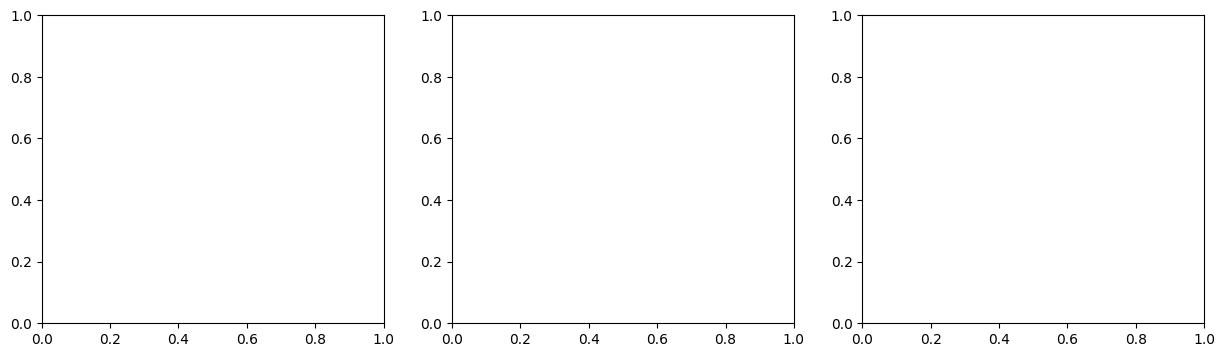

In [4]:
# import matplotlib.pyplot as plt
#
# fig, axs = plt.subplots(1, 3, figsize=(15, 4))
#
# # FIG10a
# axs[0].plot(fig10a_x, fig10a_qaoa, label='QAOA', color='C4', marker='o',
#             linestyle='-', linewidth=line_width, markersize=marker_size)
# axs[0].set_xticks(fig10a_x)
# axs[0].set_xticklabels(fig10a_xlabel, fontsize=9)
# axs[0].set_xlabel('relative cross-rack fidelity', fontsize=12)
# axs[0].set_ylabel('EPR overhead (%)', fontsize=12)
# axs[0].vlines(9, ymin=6, ymax=42, color='gray', linestyles='dashed', linewidth=1.2)
# axs[0].text(8.6, 8, 'cross-rack = in-rack', fontsize=9, rotation=90)
# axs[0].set_ylim(6, 45)
# axs[0].grid(True, axis='y', linewidth=1.0)
# axs[0].legend(fontsize=9, loc='best')
# axs[0].set_title('(a)', fontsize=13)
#
# # FIG10b
# axs[1].plot(fig10b_x, fig10b_qaoa, label='QAOA', color='C4', marker='o',
#             linestyle='-', linewidth=line_width, markersize=marker_size)
# axs[1].set_xticks(fig10b_x)
# axs[1].set_xticklabels(fig10b_xlabel, fontsize=9)
# axs[1].set_xlabel('relative distilled in-rack fidelity', fontsize=12)
# axs[1].set_ylabel('EPR overhead (%)', fontsize=12)
# axs[1].vlines(1, ymin=0, ymax=16, color='gray', linestyles='dashed', linewidth=1.2)
# axs[1].text(1, 3, 'distilled = original', fontsize=9, rotation=90)
# axs[1].grid(True, axis='y', linewidth=1.0)
# axs[1].legend(fontsize=9, loc='best')
# axs[1].set_title('(b)', fontsize=13)
#
# # FIG10c
# axs[2].plot(fig10c_x, fig10c_qaoa, label='QAOA', color='C4', marker='o',
#             linestyle='-', linewidth=line_width, markersize=marker_size)
# axs[2].set_xticks(fig10c_x)
# axs[2].set_xlabel(fig10c_xlabel, fontsize=12)
# axs[2].set_ylabel('latency', fontsize=12)
# axs[2].vlines(fig10c_x[0], ymin=0, ymax=70000, color='gray', linestyles='dashed', linewidth=1.2)
# axs[2].text(1, 700, 'no distillation', fontsize=9, rotation=90)
# axs[2].grid(True, axis='y', linewidth=1.0)
# axs[2].legend(fontsize=9, loc='best')
# axs[2].set_title('(c)', fontsize=13)
#
# plt.tight_layout()
# plt.savefig('fig/FIG_10_QAOA.pdf', bbox_inches='tight')
# plt.savefig('fig/FIG_10_QAOA.jpeg', bbox_inches='tight')
# plt.savefig('fig/FIG_10_QAOA.svg', bbox_inches='tight')
# plt.show()

FIG10c QAOA y-values: [10133.0, 10363.0, 13108.0, 10768.0, 11035.0, 10797.0, 12250.0, 12024.0, 12345.0, 12232.0]


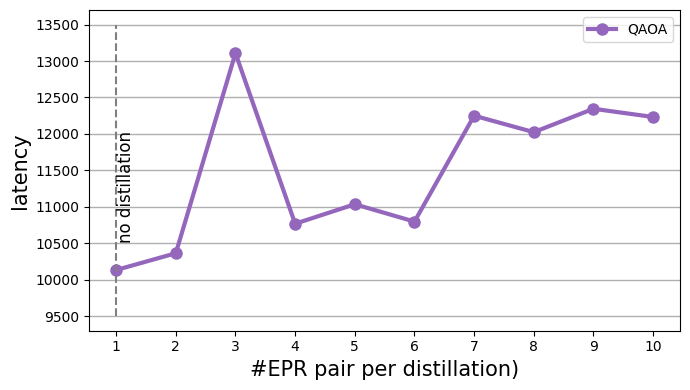

In [34]:
# =========================
# FIG10c.ipynb — QAOA-only (NO baseline), match the original styling cues:
# - same series color as the full QAOA curve (uses the same default cycle/color as original)
# - dashed vertical line at x=1 ("no distillation")
# - same x/y labels + tick labels from the source graph
#
# Run AFTER the full FIG10c cell that computes: xrange, xlabel, qaoa
# (i.e., the same variables used by the original FIG10c plot).
# =========================
import matplotlib.pyplot as plt


# Extract already-generated QAOA curve (identical to the full graph's QAOA data)
qaoa_only = list(diction_our[0][4])  # make a copy
print("FIG10c QAOA y-values:", qaoa_only)

fig, axQ = plt.subplots(1, 1, figsize=(7, 4))

# Plot with the same "default" styling behavior as the original (no custom color unless the notebook did)
# If your full FIG10c explicitly used a color for QAOA, set it here to match (e.g., color='C4').
plot_kwargs = dict(label="QAOA", marker='o')
if "marker_size" in globals():
    plot_kwargs["markersize"] = marker_size
if "line_width" in globals():
    plot_kwargs["linewidth"] = line_width

axQ.plot(xrange, qaoa_only, **plot_kwargs, color='C4')

# Match axis ticks/labels to the original figure
axQ.set_xticks(xrange)
axQ.set_xticklabels([1,2,3,4,5,6,7,8,9,10])

axQ.set_xlabel("#EPR pair per distillation)", fontsize=15)
axQ.set_ylabel("latency", fontsize=15)

# Same dashed vline at "no distillation" (x=1)
axQ.vlines(1, ymin=9500, ymax=13500, color='gray',
           linestyles='dashed', linewidth=1.5)
axQ.text(1.02, 10500, 'no distillation', fontsize=12, rotation=90, va='bottom')

axQ.grid(True, axis="y", linewidth=1.0)
axQ.legend()

plt.tight_layout()
# optional save, matching your FIG10ab pattern
plt.savefig('fig/FIG_10c_QAOA.pdf', bbox_inches='tight')
plt.savefig('fig/FIG_10c_QAOA.jpeg', bbox_inches='tight')
plt.savefig('fig/FIG_10c_QAOA.svg', bbox_inches='tight')
plt.show()
